# DataPulse — from a public API to an insight

This notebook walks the same pipeline `main.py` runs, one step at a time, so you can see what each stage does to the data.

**collect → clean → analyse → visualise → export**

The source is the [World Bank Open Data API](https://datahelpdesk.worldbank.org/knowledgebase/articles/889392) — public, no API key. Four health indicators, eight countries, 2000–2024.

In [1]:
import logging
import sys
from pathlib import Path

# Make the project importable whether the kernel starts in notebooks/ or the repo root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from src import analyze, clean, config, fetch, report, theme, visualize

logging.basicConfig(level=logging.INFO, format="%(levelname)-7s %(message)s", force=True)
pd.set_option("display.max_columns", 20, "display.width", 120)

print(f"{len(config.COUNTRIES)} countries: {', '.join(config.COUNTRIES)}")
print(f"{len(config.INDICATORS)} indicators: {', '.join(config.INDICATOR_NAMES)}")

8 countries: ARM, GEO, TUR, POL, DEU, JPN, USA, WLD
4 indicators: life_expectancy, health_expenditure_pc, infant_mortality, physicians_per_1k


## 1 · Collect

One request per indicator, all eight countries in a single call. Responses land in `data/raw/` as JSON and are reused for 24 hours, so re-running this notebook does not re-hit the API.

In [2]:
raw = fetch.fetch_all()
raw.head()

INFO    cache hit  SP.DYN.LE00.IN     SP.DYN.LE00.IN_ARM-DEU-GEO-JPN-POL-TUR-USA-WLD_2000-2024.json


INFO    cache hit  SH.XPD.CHEX.PC.CD  SH.XPD.CHEX.PC.CD_ARM-DEU-GEO-JPN-POL-TUR-USA-WLD_2000-2024.json


INFO    cache hit  SP.DYN.IMRT.IN     SP.DYN.IMRT.IN_ARM-DEU-GEO-JPN-POL-TUR-USA-WLD_2000-2024.json


INFO    cache hit  SH.MED.PHYS.ZS     SH.MED.PHYS.ZS_ARM-DEU-GEO-JPN-POL-TUR-USA-WLD_2000-2024.json


INFO    combined   800 rows across 4 indicators -> combined_raw.csv


,country_code,country,indicator_id,indicator,year,value
0,ARM,Armenia,SP.DYN.LE00.IN,life_expectancy,2024,78.319512
1,ARM,Armenia,SP.DYN.LE00.IN,life_expectancy,2023,77.465854
2,ARM,Armenia,SP.DYN.LE00.IN,life_expectancy,2022,74.765854
3,ARM,Armenia,SP.DYN.LE00.IN,life_expectancy,2021,72.278049
4,ARM,Armenia,SP.DYN.LE00.IN,life_expectancy,2020,73.375610


The API answers with a nested envelope — `[metadata, rows]`, each row carrying `country` and `indicator` as sub-objects. `records_to_frame` flattens that into columns. What arrives is *not* analysis-ready:

In [3]:
print(f"rows: {len(raw):,}")
print(f"missing values: {raw['value'].isna().sum()} ({raw['value'].isna().mean():.1%})")

raw.groupby("indicator")["value"].agg(["count", "mean", "min", "max"]).round(2)

rows: 800
missing values: 67 (8.4%)


,count,mean,min,max
indicator,,,,
health_expenditure_pc,194,2448.75,25.66,13473.19
infant_mortality,200,12.34,1.80,53.30
life_expectancy,200,76.23,67.65,84.56
physicians_per_1k,139,3.06,1.30,7.51


## 2 · Clean

Six passes, each one visible in the log below:

1. drop rows without a real ISO-3 country code or year
2. de-duplicate on (country, indicator, year)
3. null out impossible values — none of these indicators can be negative
4. expand to a complete country × indicator × year grid so *missing* is explicit
5. drop series covering less than half the period — too sparse to trend honestly
6. interpolate gaps of at most two years, and flag every point that was filled

In [4]:
tidy = clean.clean(raw)
wide = clean.to_wide(tidy)
wide.head()

INFO    structural  dropped 0 of 800 rows


INFO    sparse      dropped WLD/physicians_per_1k (12% coverage)


INFO    sparse      dropped USA/physicians_per_1k (28% coverage)


INFO    sparse      dropped JPN/physicians_per_1k (48% coverage)


INFO    clean       725 rows | 8 countries | 4 indicators | 98.1% populated


,country_code,country,year,life_expectancy,health_expenditure_pc,infant_mortality,physicians_per_1k
0,ARM,Armenia,2000,72.880488,25.660637,27.8,2.652
1,ARM,Armenia,2001,72.975610,31.907259,26.3,2.590
2,ARM,Armenia,2002,72.826829,59.209839,25.0,2.545
3,ARM,Armenia,2003,72.826829,66.315773,23.6,2.439
4,ARM,Armenia,2004,73.026829,71.650742,22.4,2.443


Note what got dropped: physicians-per-1,000 is reported irregularly, so the world aggregate, the USA and Japan fall below the 50% coverage floor. Keeping them would have produced a "trend" drawn through three points.

In [5]:
coverage = clean.coverage(tidy)
print(f"interpolated points: {int(tidy['is_imputed'].sum())}")
coverage.head(8)

interpolated points: 0


,country_code,indicator,observed,years,coverage
3,ARM,physicians_per_1k,23,25,0.92
7,DEU,physicians_per_1k,23,25,0.92
22,TUR,physicians_per_1k,23,25,0.92
0,ARM,health_expenditure_pc,24,25,0.96
11,GEO,physicians_per_1k,24,25,0.96
12,JPN,health_expenditure_pc,24,25,0.96
19,TUR,health_expenditure_pc,24,25,0.96
8,GEO,health_expenditure_pc,24,25,0.96


## 3 · Analyse

Endpoints are each series' own first and last *observed* year — a country that stops reporting in 2022 is measured over its own span, not credited with two extra years.

In [6]:
trends = analyze.trend_summary(tidy)

life = trends[trends["indicator"] == "life_expectancy"].sort_values("abs_change", ascending=False)
life[["country", "first_year", "first_value", "last_year", "last_value", "abs_change", "cagr"]].round(3)

INFO    trends      summarised 29 country/indicator series


,country,first_year,first_value,last_year,last_value,abs_change,cagr
28,World,2000,67.650,2024,73.482,5.831,0.003
21,Turkiye,2000,71.931,2024,77.421,5.490,0.003
2,Armenia,2000,72.880,2024,78.320,5.439,0.003
17,Poland,2000,73.749,2024,78.410,4.661,0.003
10,Georgia,2000,70.091,2024,74.657,4.566,0.003
14,Japan,2000,81.076,2024,84.036,2.960,0.001
6,Germany,2000,77.927,2024,80.793,2.866,0.002
25,United States,2000,76.637,2024,78.890,2.254,0.001


The countries that started lowest gained the most — Türkiye, Armenia and Georgia all added more years than Japan or Germany, which were already near the top. That is convergence, not a reversal of rank.

The 2020–21 dip is visible in the year-over-year table:

In [7]:
yoy = analyze.year_over_year(tidy)
covid = yoy[(yoy["indicator"] == "life_expectancy") & yoy["year"].between(2019, 2022)]
covid.pivot_table(index="country", columns="year", values="yoy_change").round(2)

year,2019,2020,2021,2022
country,,,,
Armenia,0.60,-2.85,-1.10,2.49
Georgia,0.18,-0.66,-1.87,2.51
Germany,0.40,-0.25,-0.25,-0.18
Japan,0.15,0.20,-0.11,-0.45
Poland,0.30,-1.50,-1.05,1.80
Turkiye,0.28,-1.21,-0.80,1.87
United States,0.15,-1.81,-0.65,1.10
World,0.23,-0.69,-0.97,1.75


In [8]:
analyze.rank_latest(tidy, "infant_mortality")[["rank", "country", "latest_year", "latest_value"]]

,rank,country,latest_year,latest_value
0,1,Japan,2024,1.8
1,2,Germany,2024,3.1
2,3,Poland,2024,3.6
3,4,United States,2024,5.5
4,5,Georgia,2024,7.5
5,6,Turkiye,2024,8.0
6,7,Armenia,2024,8.5
7,8,World,2024,27.7


In [9]:
analyze.indicator_correlation(wide).round(2)

,life_expectancy,health_expenditure_pc,infant_mortality,physicians_per_1k
life_expectancy,1.00,0.57,-0.78,0.00
health_expenditure_pc,0.57,1.00,-0.50,0.28
infant_mortality,-0.78,-0.50,1.00,-0.29
physicians_per_1k,0.00,0.28,-0.29,1.00


Life expectancy and infant mortality are strongly inversely correlated (r ≈ −0.78), which is the expected shape. Spending correlates with life expectancy far more weakly (r ≈ 0.57) — and that column is in *current US$*, so part of what it measures is inflation rather than care.

## 4 · Visualise

Figures are written to `figures/`. Colour is assigned by role from a colourblind-safe pair, and identity never rests on colour alone — every chart carries direct labels, dashes or a legend.

INFO    trends      summarised 29 country/indicator series


INFO    analysis    wrote 5 tables -> C:\Users\sakan\Desktop\DataPulse\data\processed


INFO    figure      figures\01_life_expectancy_trend.png


INFO    figure      figures\02_arm_indicator_panels.png


INFO    figure      figures\03_spend_vs_life_expectancy.png


INFO    figure      figures\04_life_expectancy_change.png


INFO    figure      figures\05_indicator_correlation.png


INFO    figures     5 rendered in light theme


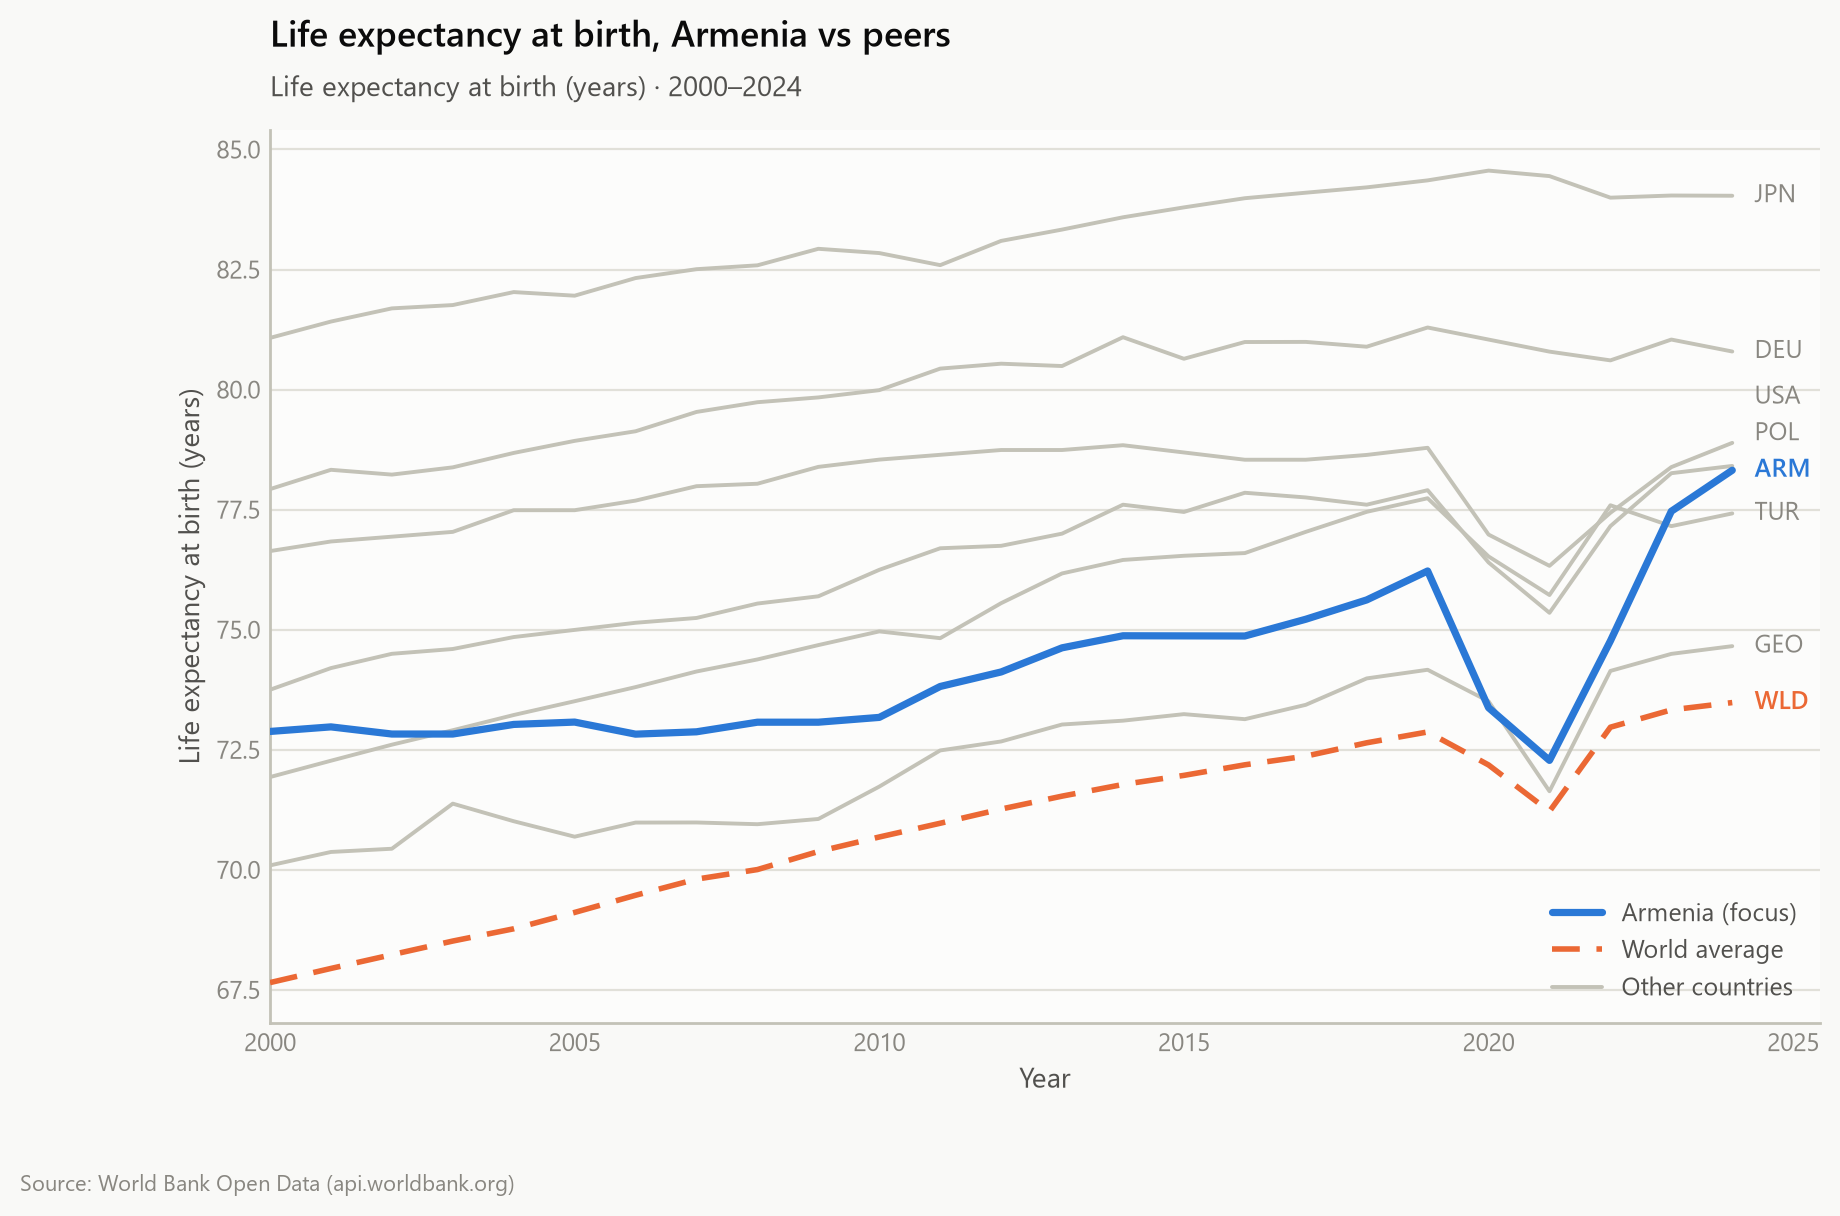

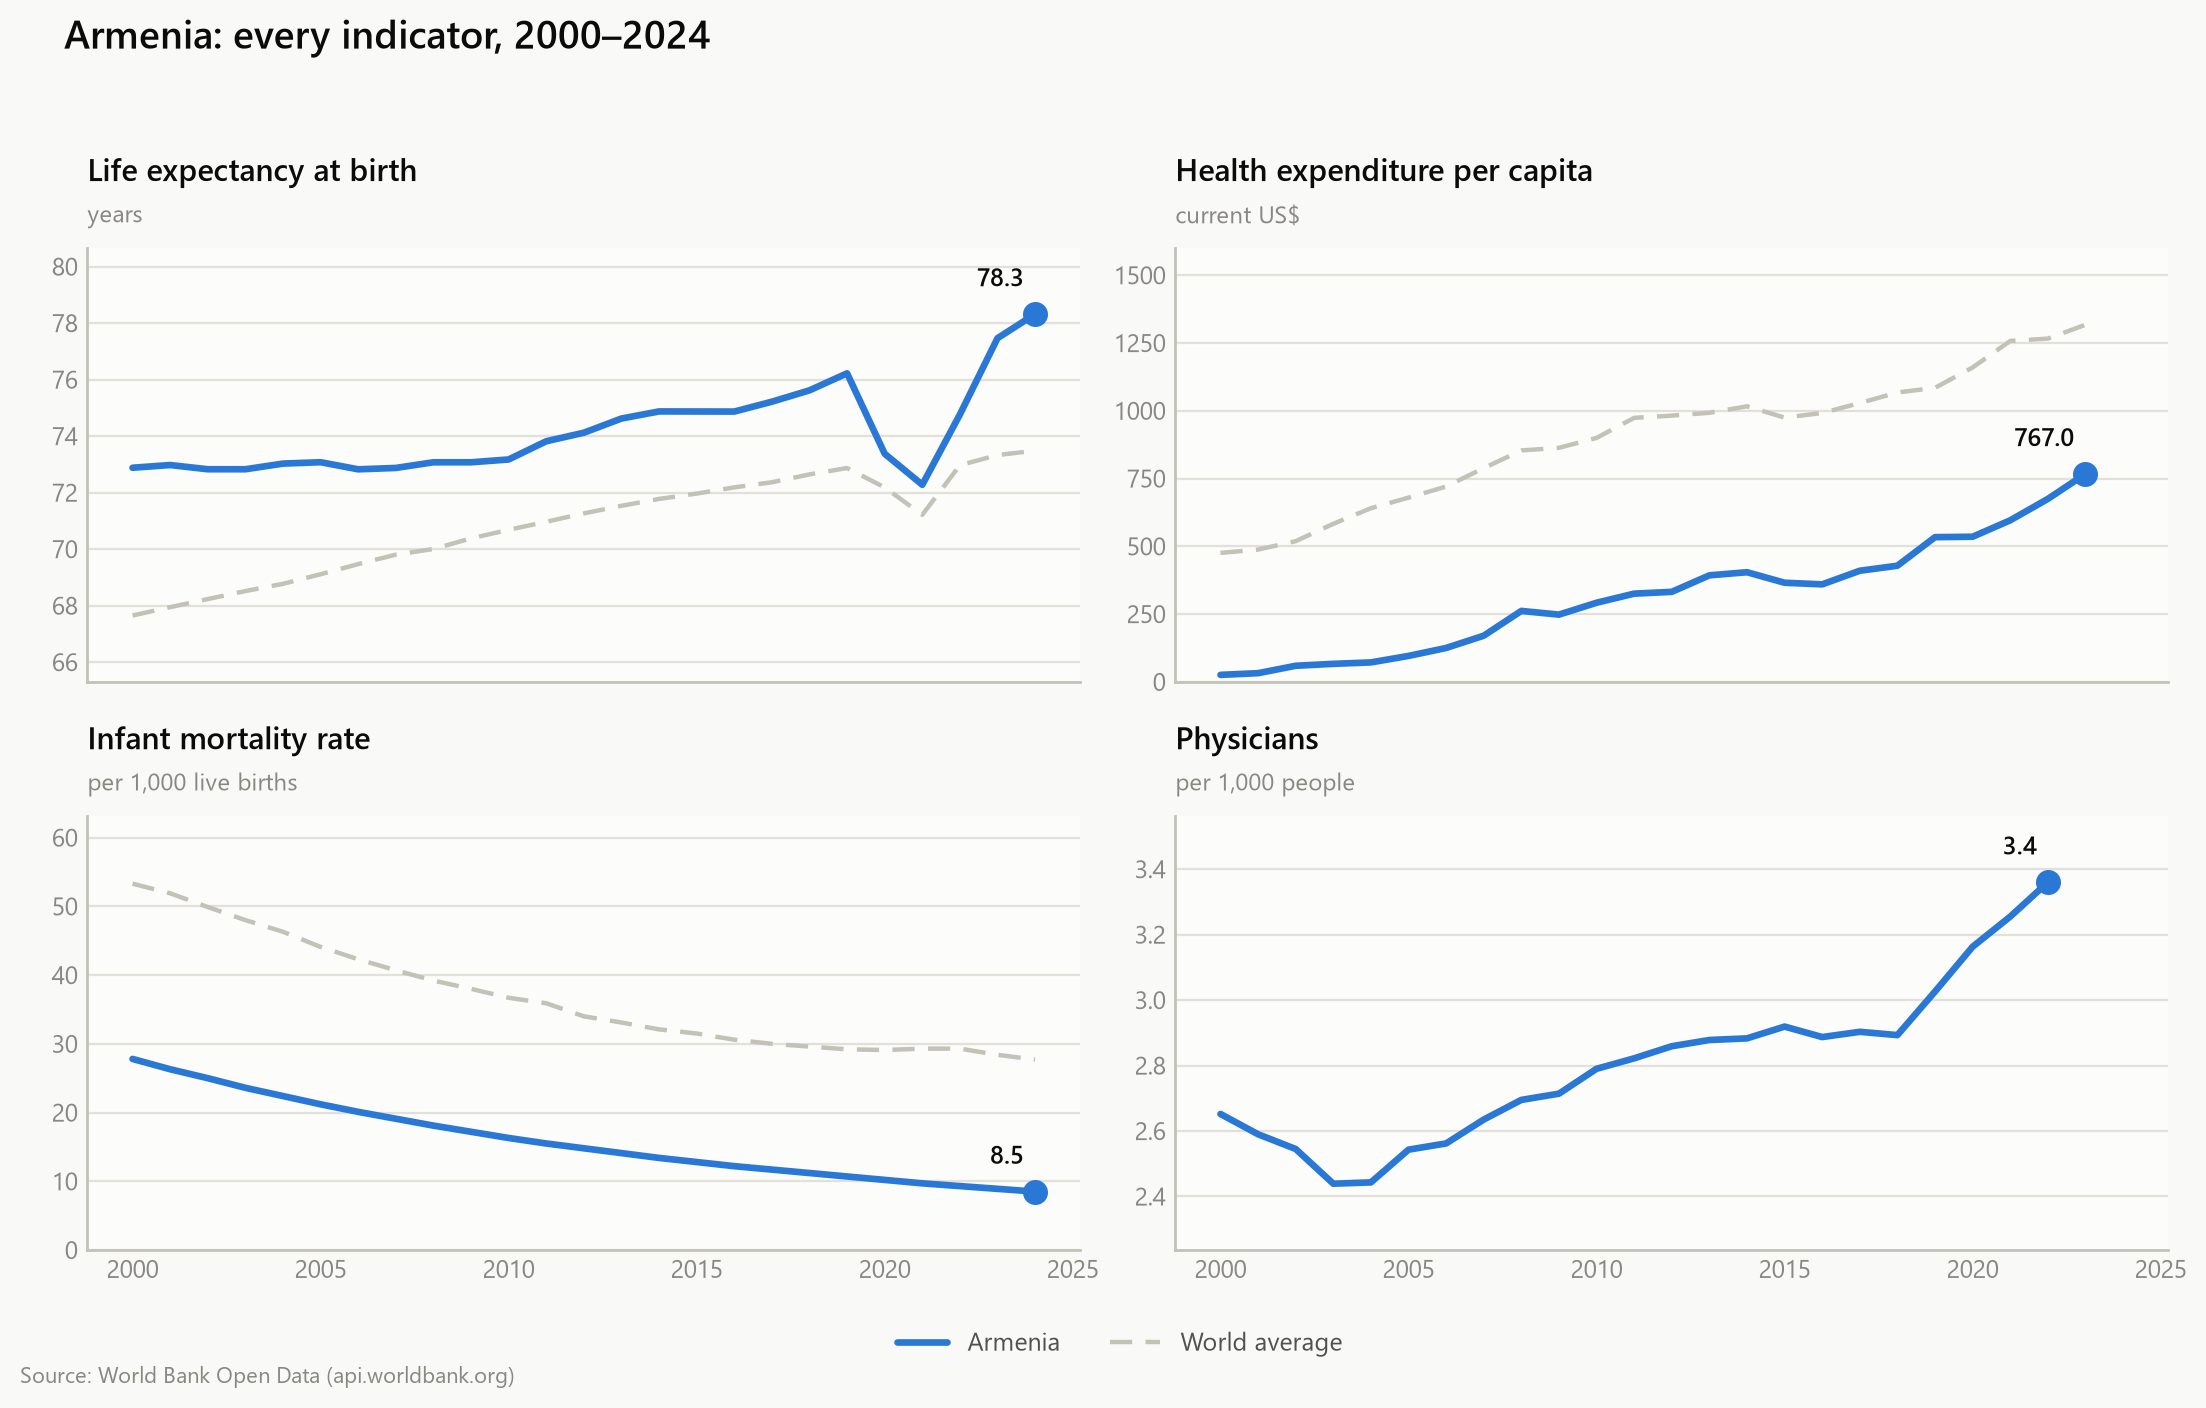

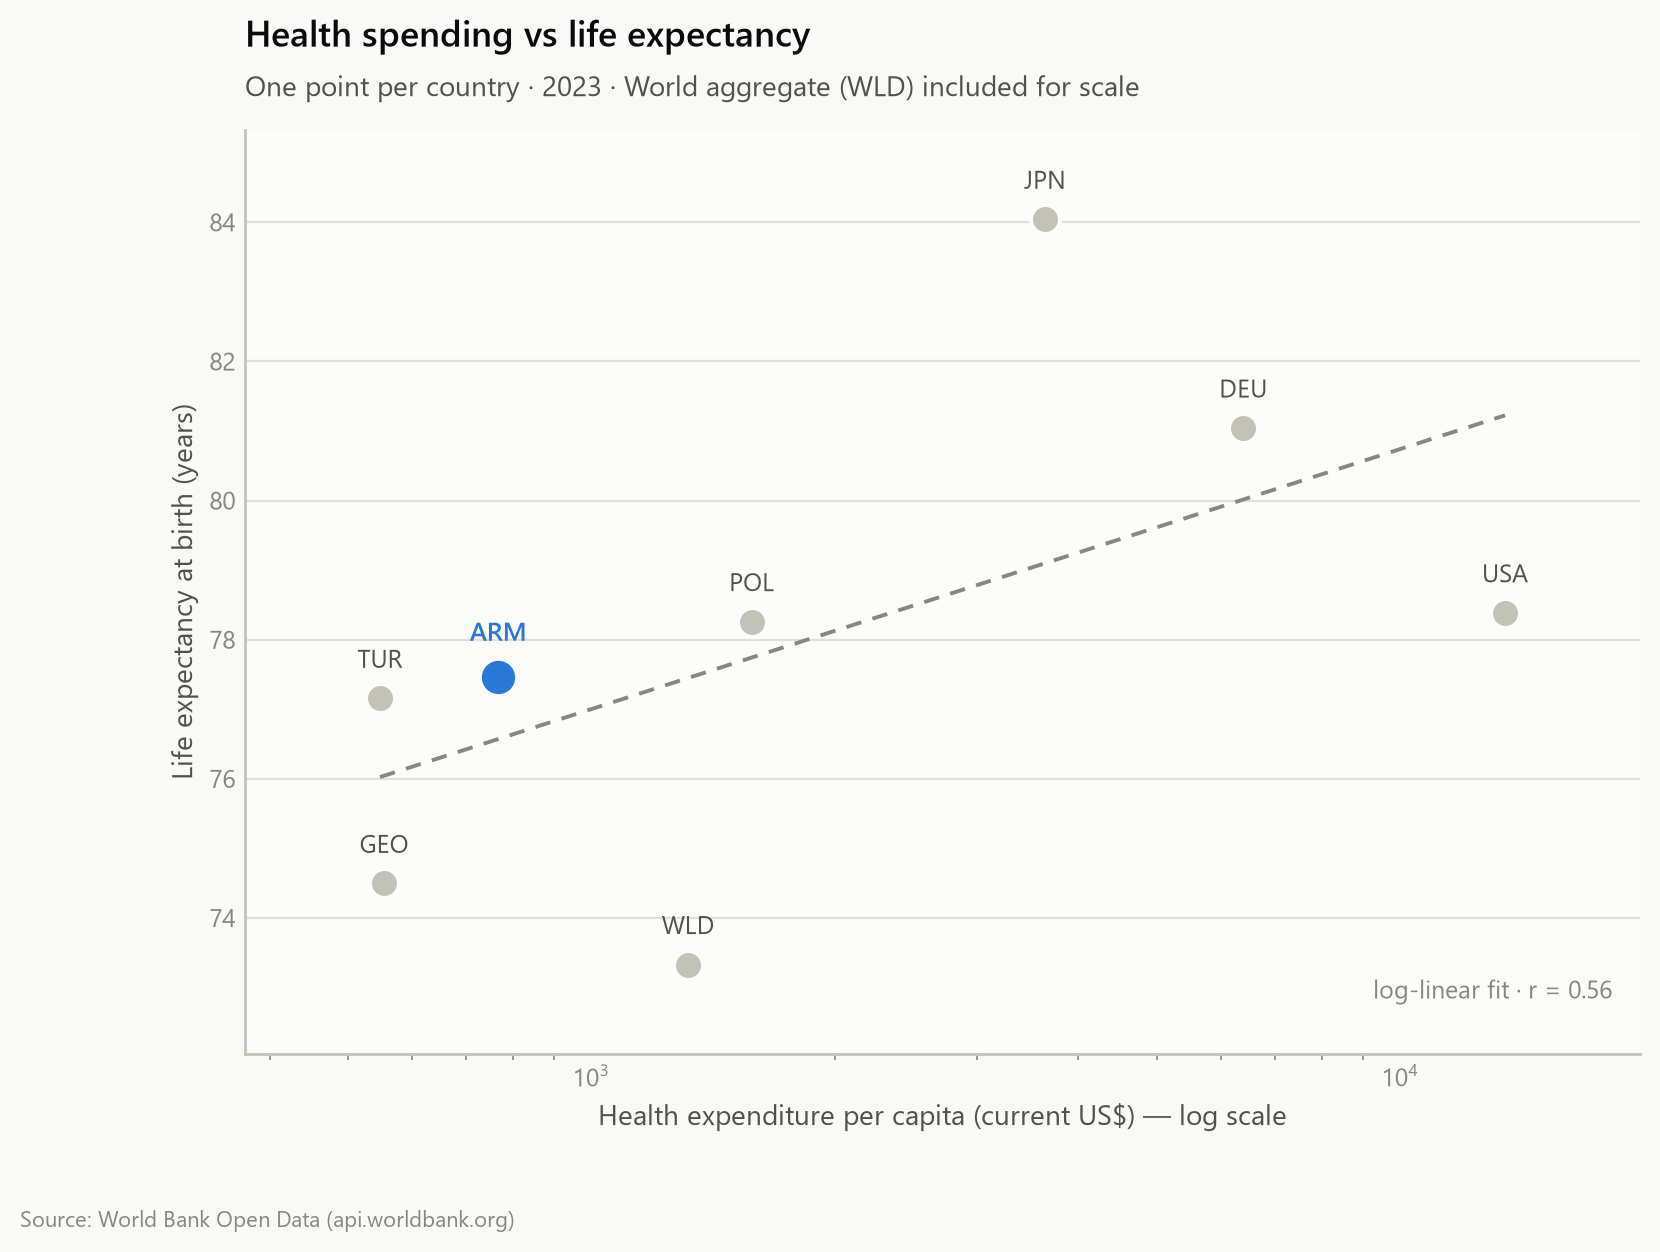

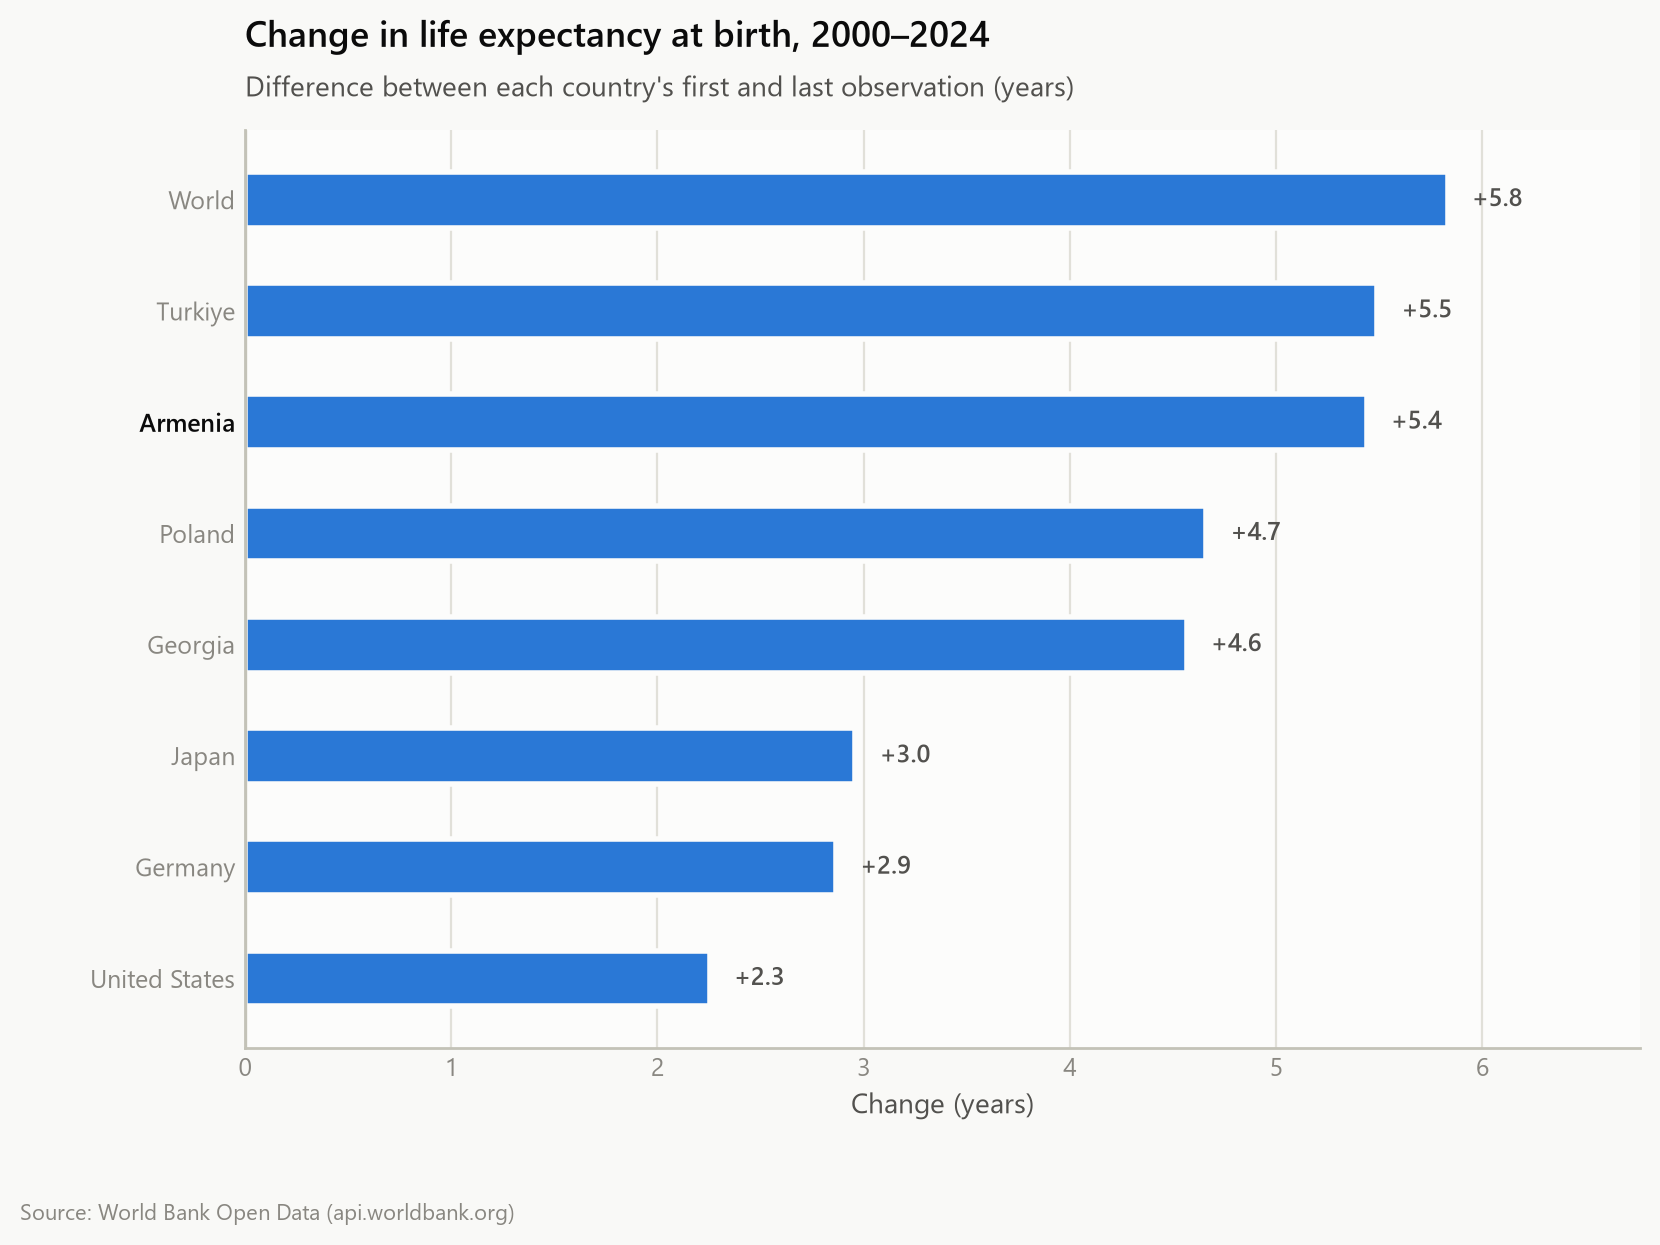

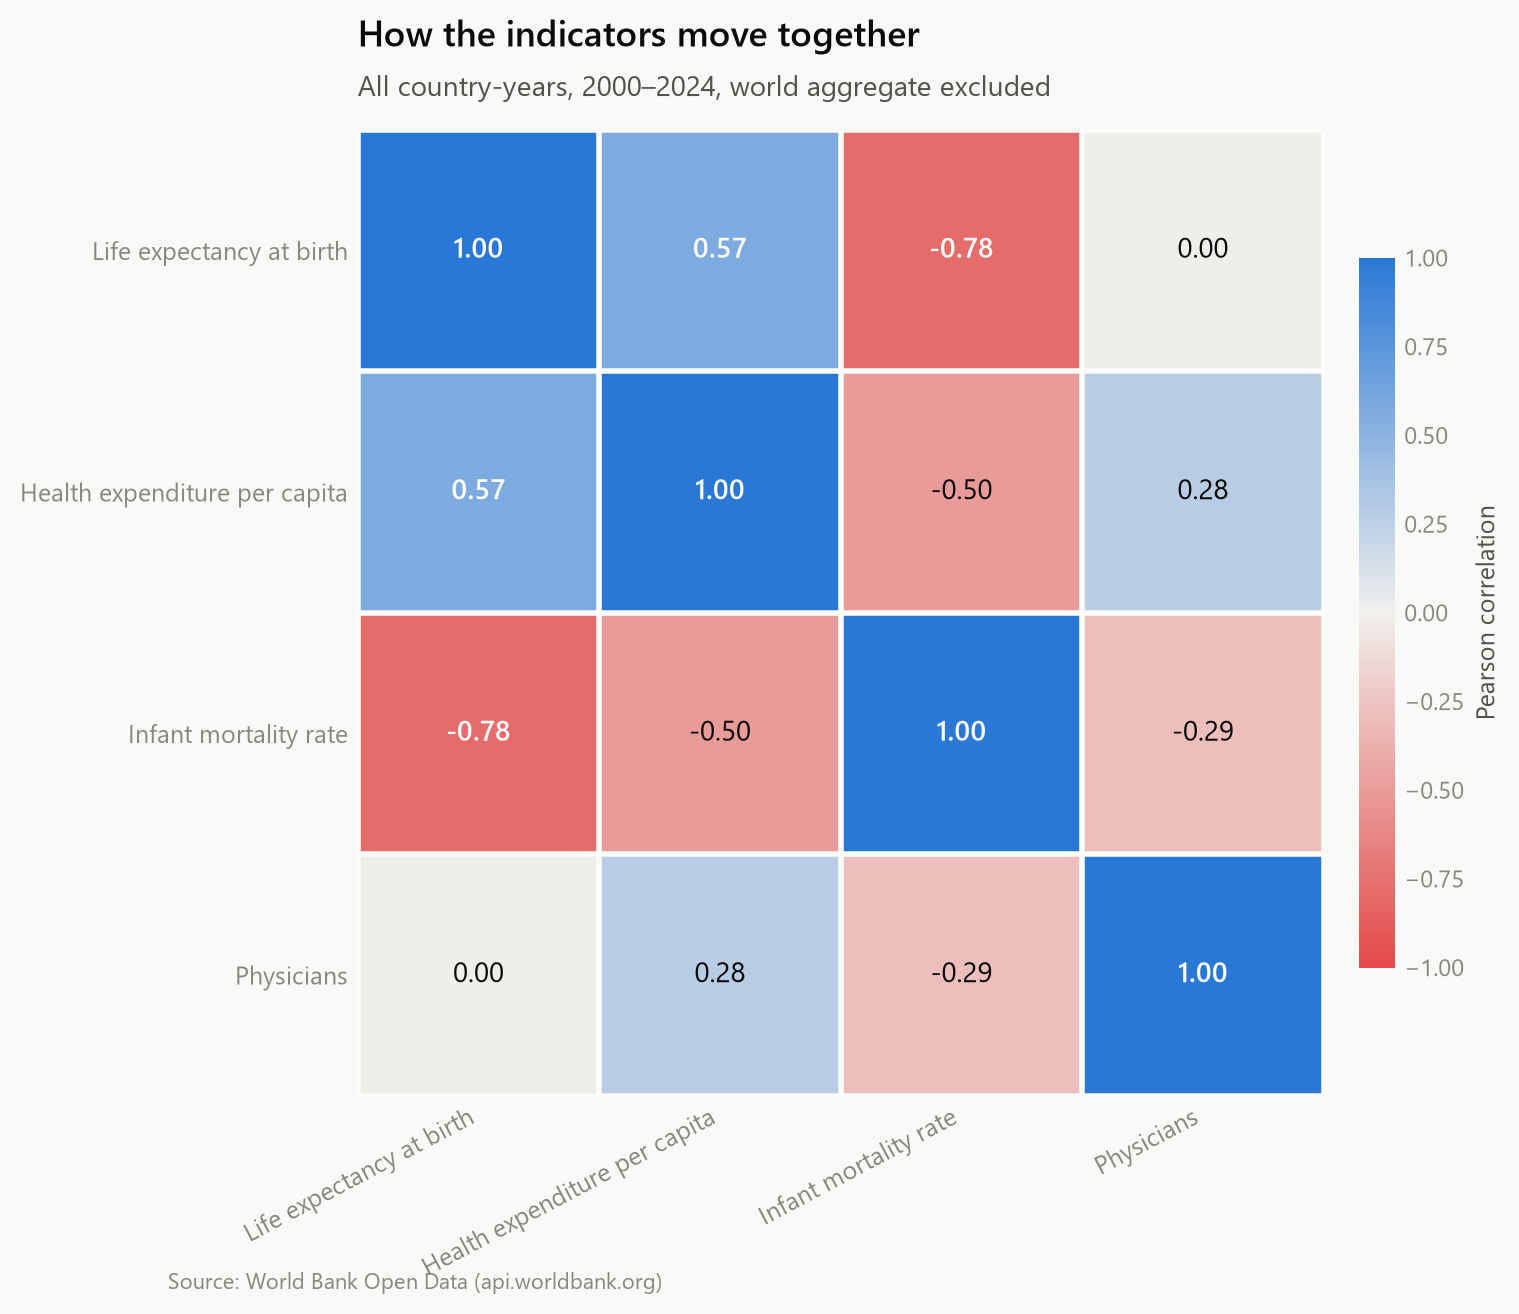

In [10]:
tables = analyze.analyze(tidy, wide)
figures = visualize.render_all(tidy, wide, tables, theme_name="light")

for path in figures:
    display(Image(filename=str(path), width=820))

## 5 · Export

The same tables become a Markdown report in `reports/insights.md`.

In [11]:
path = report.build_report(tidy, tables, figures)
print(path.read_text(encoding="utf-8")[:900])

INFO    report      reports\insights.md


# DataPulse — health indicator insights

*Generated 2026-08-10 15:40 UTC · 2000–2024 · 8 countries · 4 indicators · focus: Armenia*

## Headline insights

- **Health expenditure per capita** in Armenia moved from 25.7 (2000) to 767.0 (2023) — +741.3 current US$, a nominal rise (current US$, so the movement mixes real spending growth with inflation and exchange-rate changes).
- **Infant mortality rate** in Armenia moved from 27.8 (2000) to 8.5 (2024) — -19.3 per 1,000 live births, an improvement.
- **Life expectancy at birth** in Armenia moved from 72.9 (2000) to 78.3 (2024) — +5.4 years, an improvement.
- **Physicians** in Armenia moved from 2.7 (2000) to 3.4 (2022) — +0.7 per 1,000 people, an improvement.
- The strongest relationship in the panel is **Life expectancy at birth** vs **Infant mortality rate** (r = -0.78 across all country-years).

## Life expectancy by country

| Country |


## What the data says

- **Armenia gained 5.4 years of life expectancy** between 2000 and 2024 (72.9 → 78.3), a larger gain than Germany, Japan or the United States over the same period — the countries starting furthest behind closed the most ground.
- **Infant mortality fell by roughly two thirds** (27.8 → 8.5 per 1,000), the single largest proportional improvement in the panel.
- **The 2020–21 shock is unmistakable, and the recovery is uneven.** By 2023 Armenia, Georgia, Poland and the world average were back above their 2019 level; Germany, Japan, Türkiye and the United States were still below it.
- **Money buys less than the headline suggests.** Across all country-years, spending per capita explains far less of life expectancy (r ≈ 0.57, on a log scale) than infant mortality does (r ≈ −0.78). The United States spends several times more per person than anyone else here and still lands below the life expectancy its own trend line predicts.

### Caveats worth stating

- Health expenditure is in **current US$** — nominal, not adjusted for inflation or exchange rates, so its growth rate overstates real change.
- Interpolated points (flagged in `is_imputed`) are estimates, not observations. They are drawn hollow in the trend chart.
- Eight countries is a convenience sample chosen for regional contrast, not a representative one; the correlations describe this panel, not the world.